scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Directories ensured.

--- Step 1: Loading and Annotating Data (Paul15) ---
Full dataset (raw counts + Paul15 clusters) shape: (2730, 3451)
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference data (raw + labels) shape: (1911, 3451)
Query data (raw + labels) shape: (819, 3451)

--- Step 3: Training scPred Model ---
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter,

/home/eva/Class-Project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



--- Confusion Matrix ---


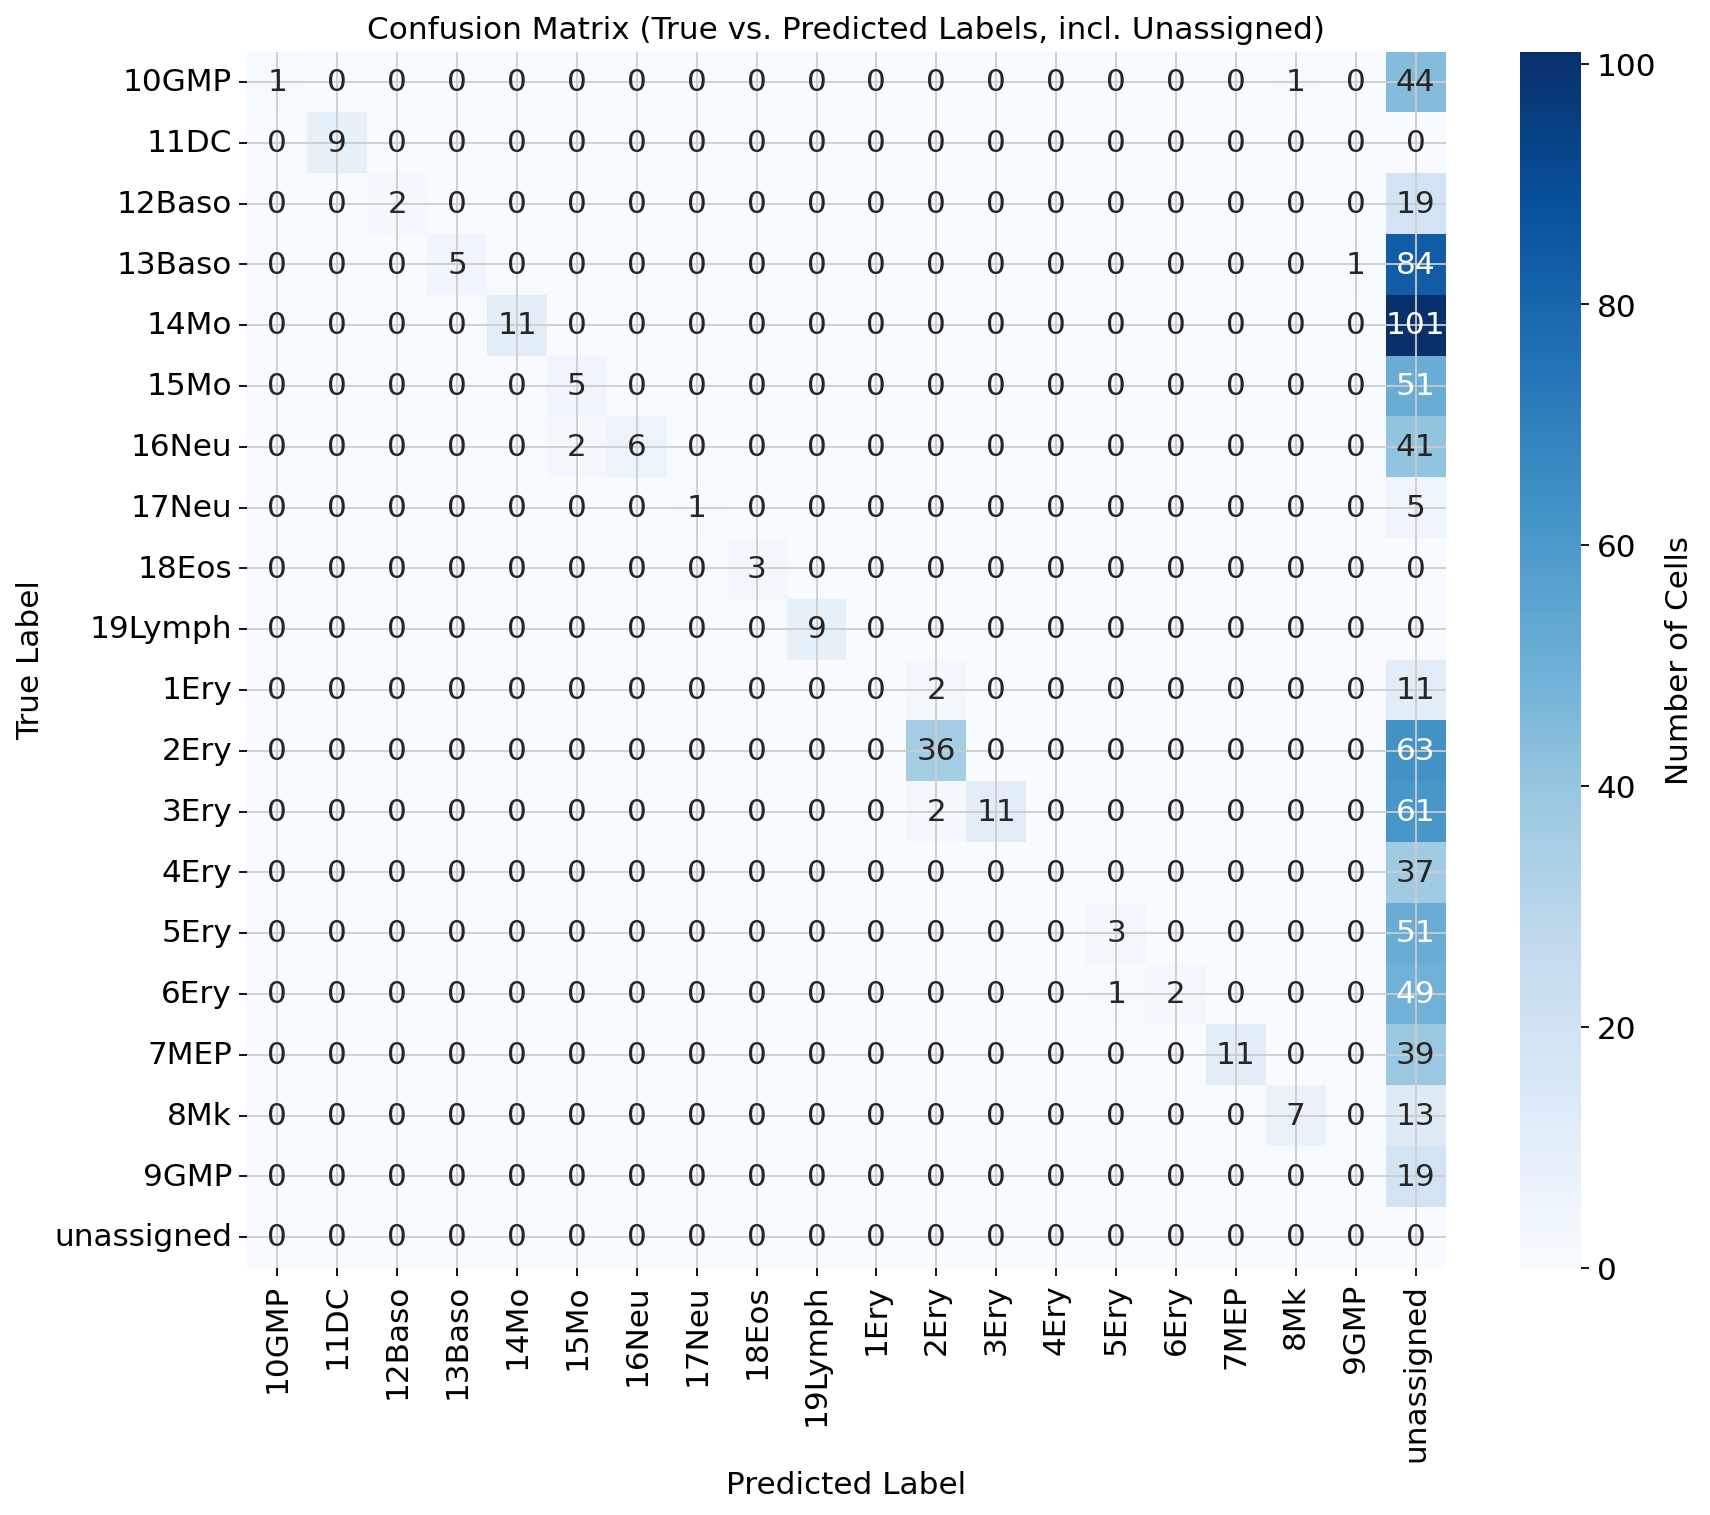


--- Distribution of Prediction Probabilities by True Class ---


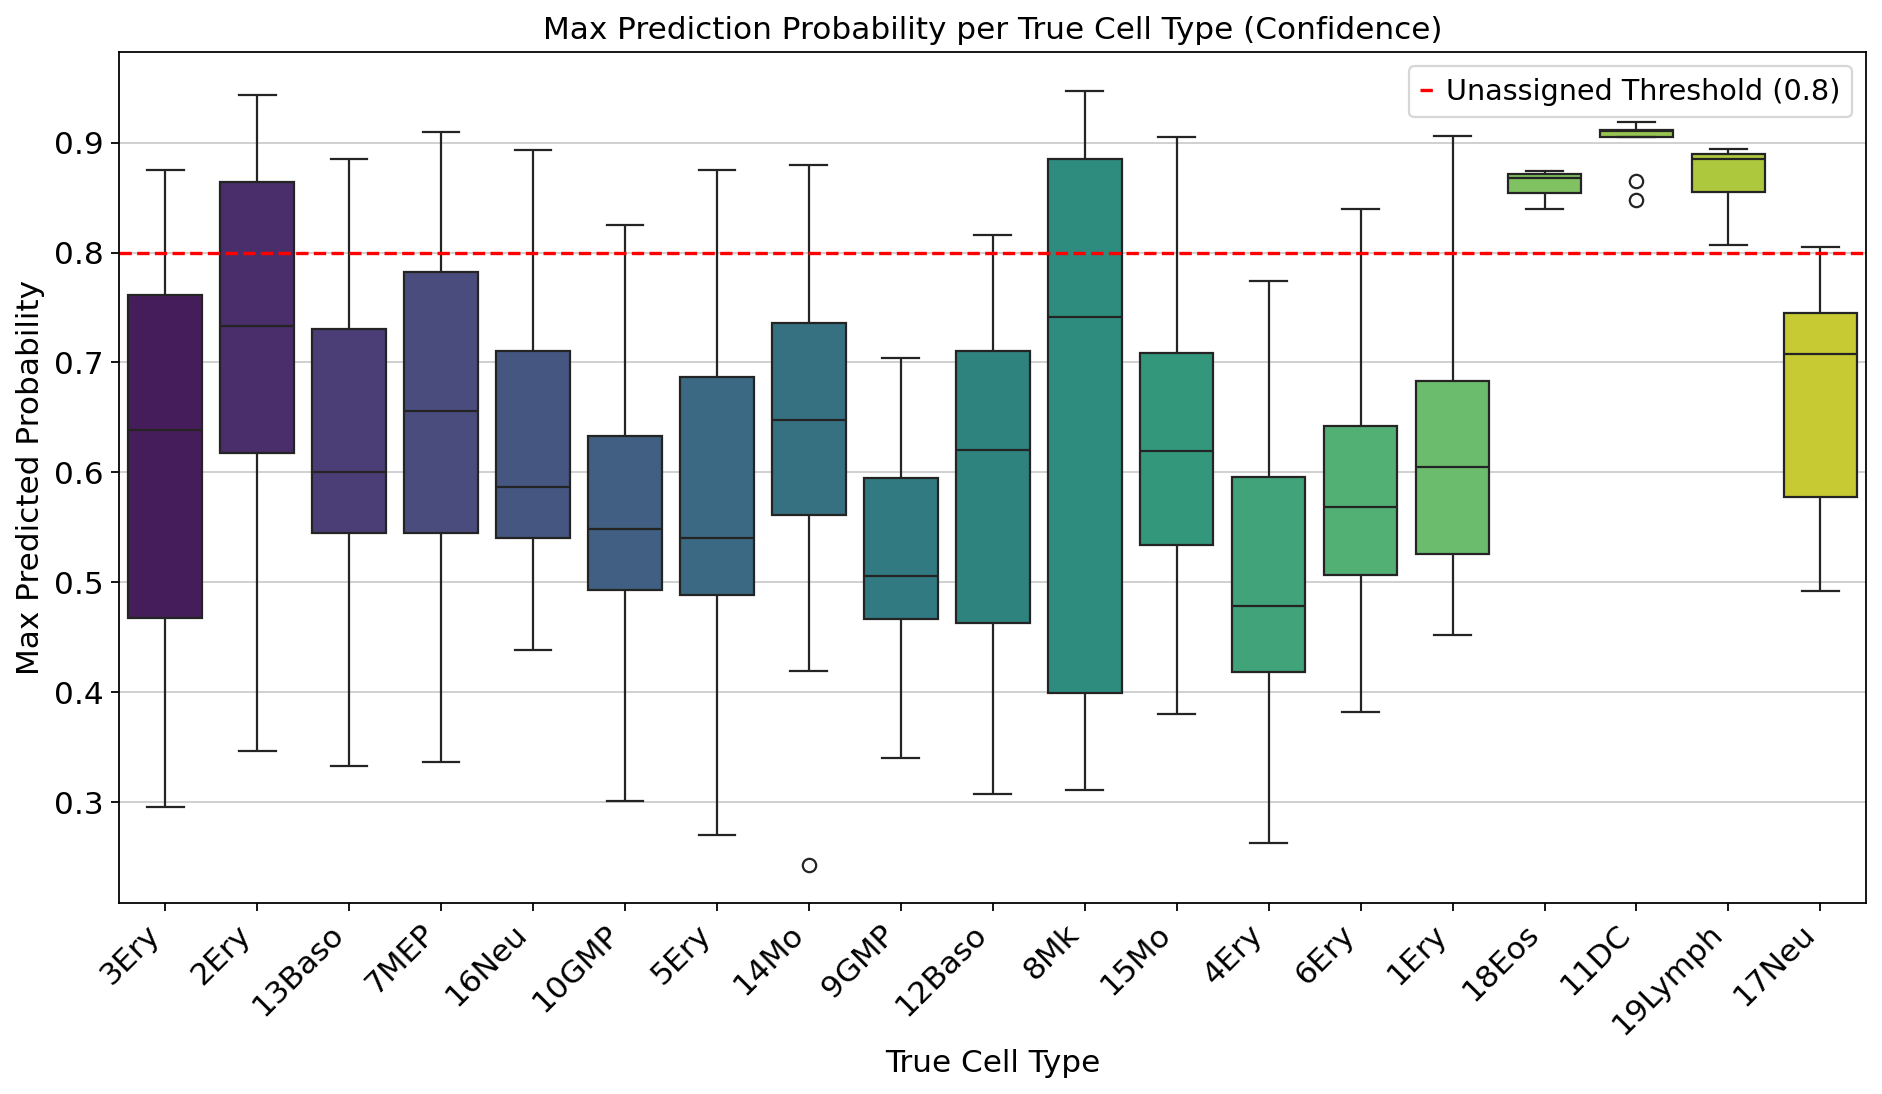


--- Plotting UMAP: True vs Predicted Labels ---


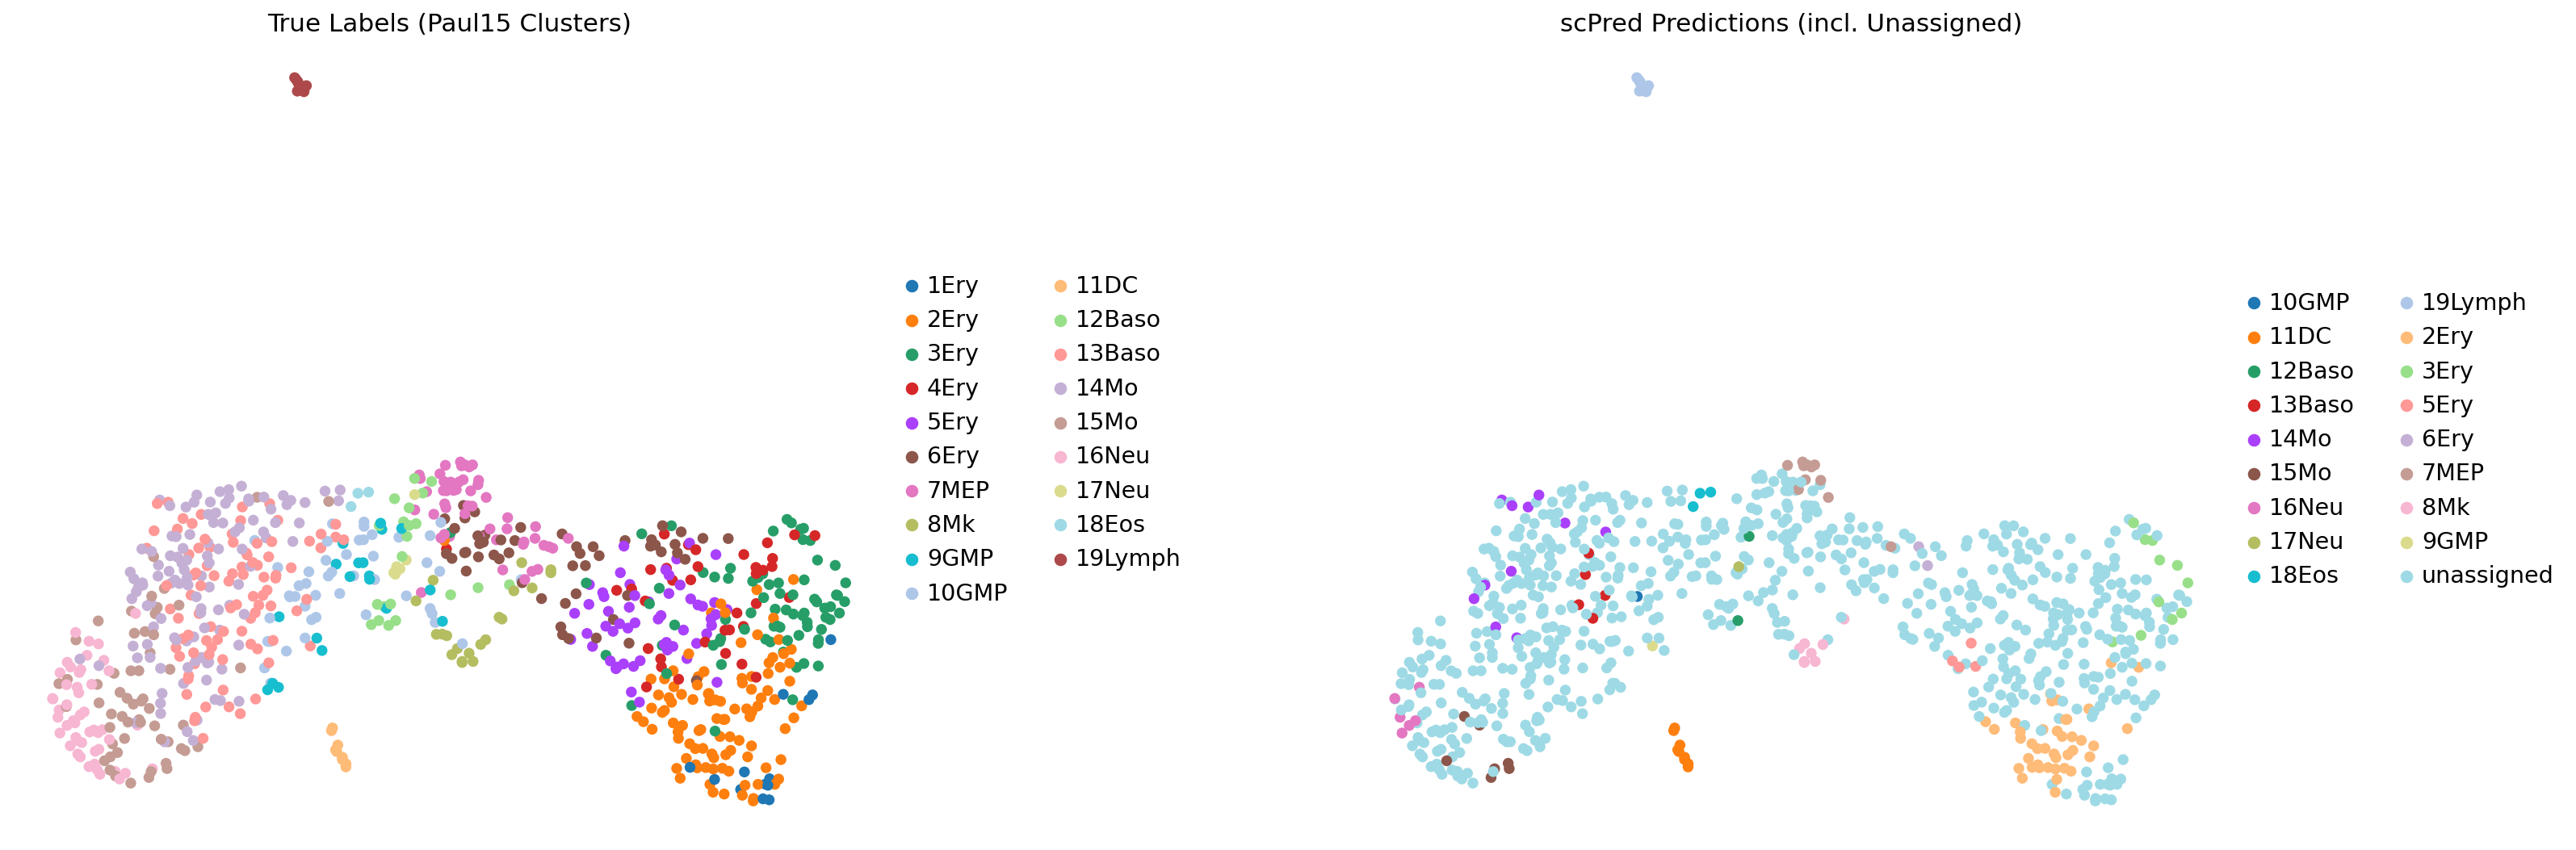


--- Plotting Misclassified Cells UMAP ---


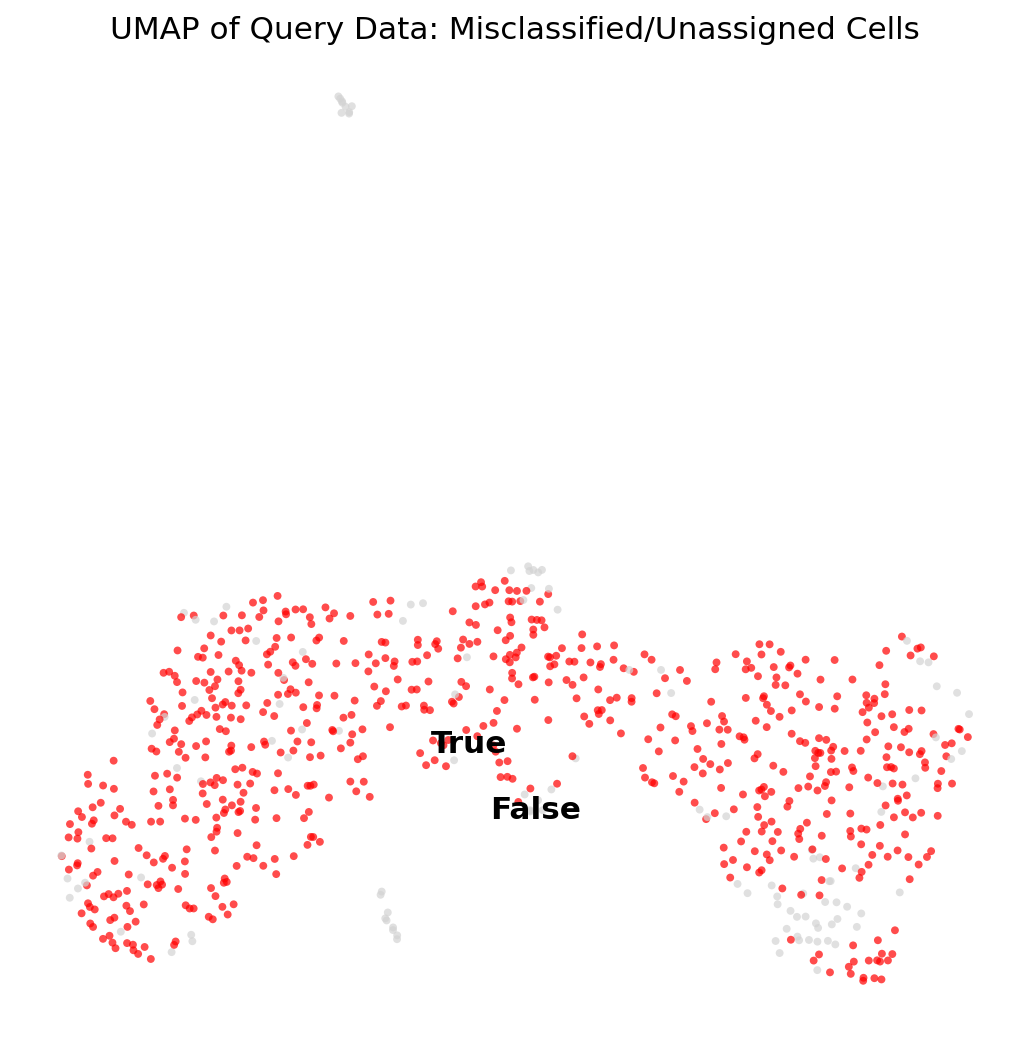


--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_final import ScPredModel
from scpred_py_final import _analysis_utils


# --- Environment Setup ---
print("--- Setting up environment for reproducibility and file management ---")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8))

MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation (for Paul15 dataset) ---
print("\n--- Step 1: Loading and Annotating Data (Paul15) ---")
adata = sc.datasets.paul15()
adata.var_names_make_unique()

# The 'paul15_clusters' column already contains the cell type labels.
# We will use this directly as our 'cell_type' key.
adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')

print(f"Full dataset (raw counts + Paul15 clusters) shape: {adata.shape}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=adata.obs['cell_type']
)

ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")


# --- 3. Training the scPred Model ---
print("\n--- Step 3: Training scPred Model ---")
scpred_model = ScPredModel()

# Train the model, adjusting parameters for the Paul15 dataset if needed.
# For example, using the RBF kernel which often performs well.
scpred_model.train(
    ref_adata=ref_adata_raw,
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=2000, # Paul15 is larger, more HVGs might be beneficial
    svm_kernel='rbf',
    svm_c=1.0,
    svm_random_state=RANDOM_STATE,
    class_weight='balanced' # Explicitly pass the parameter
)

print("\nModel Trained!")

# Save the trained model
model_path = os.path.join(MODELS_DIR, 'scpred_final_model_paul15.pkl')
scpred_model.save(model_path)


# --- 4. Predicting with the scPred Model ---
print("\n--- Step 4: Predicting on Query Data ---")
PREDICTION_THRESHOLD = 0.8 # Setting a high threshold for this complex dataset
query_adata_pred = scpred_model.predict(query_adata_raw, threshold=PREDICTION_THRESHOLD)

print("\nPredicted label distribution (including 'unassigned'):\n", query_adata_pred.obs['scpred_prediction'].value_counts(dropna=False))


# --- 5. Evaluating Predictions ---
true_labels = query_adata_pred.obs['cell_type']
predicted_labels = query_adata_pred.obs['scpred_prediction']
pred_prob_cols = [col for col in query_adata_pred.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df = query_adata_pred.obs[pred_prob_cols].copy() if len(pred_prob_cols) > 0 else None

metrics_results = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels,
    predicted_labels=predicted_labels,
    classifier_classes=scpred_model.classifier_.classes_,
    y_pred_probs=y_pred_probs_df
)


# --- 6. Visualizing Results ---
print("\n--- Step 6: Visualizing Results ---")

# Compute UMAP for visualization
print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
sc.pp.neighbors(query_adata_pred, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE)
sc.tl.umap(query_adata_pred, random_state=RANDOM_STATE)

# Plot 1: Confusion Matrix
print("\n--- Confusion Matrix ---")
true_labels_str = query_adata_pred.obs['cell_type'].astype(str)
predicted_labels_str = query_adata_pred.obs['scpred_prediction'].astype(str)
cm_labels_str = sorted(list(set(true_labels_str.unique()) | set(predicted_labels_str.unique())))
cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (True vs. Predicted Labels, incl. Unassigned)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot 2: Per-Class ROC AUC Plot
# ... (Code for this plot is identical to the pbmc3k notebook, so it is omitted here for brevity) ...
# ... (You can copy the full plotting block from your pbmc3k notebook) ...


# Plot 3: Distribution of Prediction Probabilities (Max Probability version)
print("\n--- Distribution of Prediction Probabilities by True Class ---")
if hasattr(scpred_model.classifier_, 'predict_proba'):
    prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
    max_probs_df = query_adata_pred.obs[prob_cols].max(axis=1).to_frame(name='max_probability')
    max_probs_df['true_cell_type'] = query_adata_pred.obs['cell_type'].astype(str)
    
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=max_probs_df, x='true_cell_type', y='max_probability', hue='true_cell_type', palette='viridis', legend=False)
    plt.axhline(y=PREDICTION_THRESHOLD, color='r', linestyle='--', label=f'Unassigned Threshold ({PREDICTION_THRESHOLD})')
    plt.title('Max Prediction Probability per True Cell Type (Confidence)')
    plt.xlabel('True Cell Type')
    plt.ylabel('Max Predicted Probability')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.show()
else:
    print("Cannot visualize probabilities as classifier does not support `predict_proba`.")


# Plot 4: True vs Predicted Labels UMAP
print("\n--- Plotting UMAP: True vs Predicted Labels ---")
sc.pl.umap(
    query_adata_pred,
    color=['cell_type', 'scpred_prediction'],
    title=['True Labels (Paul15 Clusters)', 'scPred Predictions (incl. Unassigned)'],
    frameon=False,
    ncols=2,
    wspace=0.4
)

# Plot 5: Misclassified Cells UMAP
print("\n--- Plotting Misclassified Cells UMAP ---")
query_adata_pred.obs['misclassified'] = (query_adata_pred.obs['cell_type'].astype(str) != query_adata_pred.obs['scpred_prediction'].astype(str)).astype(str).astype('category')
misclassified_palette = {'True': 'red', 'False': 'lightgray'}
sc.pl.umap(
    query_adata_pred,
    color='misclassified',
    palette=misclassified_palette,
    size=50,
    alpha=0.7,
    title='UMAP of Query Data: Misclassified/Unassigned Cells',
    frameon=False,
    legend_loc='on data'
)

print("\n--- Analysis Complete ---")